# Au [100] benchmark: F-MS vs AS-MS vs WP-MS vs KG ODE

Thickness sweep for Au [100] comparing Fresnel multislice, angular-spectrum multislice, wave-propagation multislice, and the second-order KG ODE. Publication plots use the ODE result as the numerical reference curve.

**Methods**: F-MS (paraxial), AS-MS (non-paraxial vacuum propagation), WP-MS (local-medium propagation), and the second-order KG ODE

**Parameters**: Au FCC, a = 4.08 Å, 300 keV, 256 slices/cell, and one finite-projection Lobato potential shared by all four methods.

In [1]:
%matplotlib inline

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".1"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from tqdm.auto import tqdm

plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

from wide_angle_propagation.notebook_utils import (
    beam_amplitude_normalized,
    beam_for_angle_mrad,
    curve_rmse,
    global_phase_removed,
    objective_lens_transfer_function,
    resolve_paper_figures_dir,
    resolve_repo_root,
    shared_percentile_limits,
    simulate_fresnel_as_exit_only,
    simulate_wpm_exit_only,
)
import wide_angle_propagation.propagation_methods as propagation_methods_module
from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel,
    energy2wavelength,
    fresnel_propagation_kernel,
    simulate_fresnel_as,
    simulate_kg_ode_full,
    simulate_wpm,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)
print(f"Propagation module: {propagation_methods_module.__file__}")


Propagation module: /home/dl277493/Documents/Code/WideAnglePropagation-main/wide_angle_propagation/propagation_methods.py


## Crystal setup and common Lobato potential

Au FCC, a = 4.08 Å, 256 slices/cell, no thermal motion. The same slice-averaged finite-projection Lobato potential is passed to Fresnel MS, angular-spectrum MS, WP-MS, and the second-order ODE so the comparison changes only the propagation method.

In [2]:
# --- Crystal parameters ---
a_central = 4.08
n_slices_per_cell = 256
energy = 300e3
n_cells_range = range(0, 101)
gpts = (128, 128)
WPM_N_BINS = 256
POTENTIAL_PARAMETRIZATION = "lobato"
POTENTIAL_PROJECTION = "finite"
INDEX_MODEL = "kg"
MS_PHASE_CONVENTION = "paraxial_n2"

beam_target_mrad = 135.0
beam_target_axis = "y"

atoms = bulk("Au", "fcc", a=a_central, cubic=True)
atoms.info['thermal_sigma'] = 0.0
atoms.arrays['thermal_sigma'] = np.zeros(len(atoms))

ny, nx = gpts

cell_thickness = atoms.get_cell()[2, 2]
slice_dz = cell_thickness / n_slices_per_cell

# One common interaction model for every propagation method.
potential = abtem.Potential(
    atoms, gpts=gpts, slice_thickness=slice_dz,
    projection=POTENTIAL_PROJECTION,
    parametrization=POTENTIAL_PARAMETRIZATION,
)
potential_cpu = cupy.asnumpy(potential.build(lazy=False).array / slice_dz)
pot_array = jnp.array(potential_cpu)

# Plane wave and sampling
pw = abtem.PlaneWave(energy=energy)
pw.grid.match(potential)
psi0 = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))
sampling = (float(pw.grid.sampling[0]), float(pw.grid.sampling[1]))
wavelength = energy2wavelength(energy)
beam_target = beam_for_angle_mrad(gpts, sampling, wavelength, beam_target_mrad, axis=beam_target_axis)

tracked_beams = [("00", 0, 0, "Pixel [0, 0]")]
if beam_target["visible"]:
    tracked_beams.append((
        "target",
        beam_target["h"],
        beam_target["k"],
        f"Pixel [{beam_target['h']}, {beam_target['k']}] ({beam_target['actual_mrad']:.1f} mrad)",
    ))

print(f"Au FCC, a = {a_central} Å, {n_slices_per_cell} slices/cell")
print(f"dz = {slice_dz:.4f} Å, energy = {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(
    f"Grid: {ny}×{nx}, field of view = "
    f"({a_central:.4f}, {a_central:.4f}) Å"
)
print(f"Actual sampling (y, x) = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(
    f"Potential={POTENTIAL_PARAMETRIZATION}/{POTENTIAL_PROJECTION}; "
    f"index={INDEX_MODEL}; phase={MS_PHASE_CONVENTION}; "
    f"WP-MS bins={WPM_N_BINS}"
)
if beam_target["visible"]:
    print(
        f"{beam_target_mrad:.1f} mrad beam is visible on {beam_target_axis}: "
        f"using pixel [{beam_target['h']}, {beam_target['k']}] "
        f"({beam_target['actual_mrad']:.2f} mrad)."
    )
else:
    print(
        f"{beam_target_mrad:.1f} mrad beam is not visible on {beam_target_axis} "
        f"with this sampling; maximum visible angle is "
        f"{beam_target['max_visible_mrad']:.2f} mrad. Skipping that beam."
    )


Au FCC, a = 4.08 Å, 256 slices/cell
dz = 0.0159 Å, energy = 300 keV, λ = 0.0197 Å
Grid: 128×128, field of view = (4.0800, 4.0800) Å
Actual sampling (y, x) = (0.0319, 0.0319) Å
Potential=lobato/finite; index=kg; phase=paraxial_n2; WP-MS bins=256
135.0 mrad beam is visible on y: using pixel [0, 28] (135.11 mrad).


## Thickness sweep — F-MS, AS-MS, and WP-MS

Run the three FFT-based methods through 0–100 unit cells using the common Lobato potential.

In [3]:
fk = jnp.array(fresnel_propagation_kernel(ny, nx, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(ny, nx, sampling, z=slice_dz, energy=energy))

methods = ("ms", "as", "wpm")
results = {f"{method}_{beam_key}": [] for method in methods for beam_key, *_ in tracked_beams}
w_ms, w_as, w_wpm = psi0, psi0, psi0

for i in tqdm(range(len(n_cells_range)), desc="MS/WP-MS sweep"):
    if i > 0:
        w_ms = simulate_fresnel_as_exit_only(pot_array, w_ms, fk, slice_dz, energy)
        w_as = simulate_fresnel_as_exit_only(pot_array, w_as, ak, slice_dz, energy)
        w_wpm = simulate_wpm_exit_only(
            pot_array, w_wpm, slice_dz, energy, sampling, n_bins=WPM_N_BINS
        )
        w_ms = jnp.array(w_ms)
        w_as = jnp.array(w_as)
        w_wpm = jnp.array(w_wpm)

    waves = {"ms": w_ms, "as": w_as, "wpm": w_wpm}
    for method, wave in waves.items():
        wave_np = np.asarray(wave)
        for beam_key, h, k, _ in tracked_beams:
            results[f"{method}_{beam_key}"].append(beam_amplitude_normalized(wave_np, h, k))

beam_results = {k: np.array(v) for k, v in results.items()}
sweep_exit = {"ms": w_ms, "as": w_as, "wpm": w_wpm}
print(f"Sweep complete: {len(n_cells_range)} unit cells")

MS/WP-MS sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Sweep complete: 101 unit cells


## Second-order KG ODE thickness sweep (common Lobato potential)

In [4]:
kg_ode_results = {beam_key: [] for beam_key, *_ in tracked_beams}
w_kg = psi0
phi_kg = None

for i in tqdm(range(len(n_cells_range)), desc="KG ODE sweep"):
    if i > 0:
        w_kg, phi_kg, _, _ = simulate_kg_ode_full(
            pot_array, w_kg, slice_dz, energy, sampling,
            initial_phi=phi_kg, save_wavefronts=False,
        )
        w_kg = jnp.array(w_kg)

    w_kg_np = np.asarray(w_kg)
    for beam_key, h, k, _ in tracked_beams:
        kg_ode_results[beam_key].append(beam_amplitude_normalized(w_kg_np, h, k))

kg_ode_results = {key: np.array(values) for key, values in kg_ode_results.items()}
final_summary = ", ".join(
    f"{label} final: {kg_ode_results[beam_key][-1]:.6f}"
    for beam_key, _, _, label in tracked_beams
)
print(f"KG ODE {final_summary}")

results_dir = resolve_repo_root() / "notebooks" / "verification" / "results"
results_dir.mkdir(parents=True, exist_ok=True)
results_path = results_dir / "au100_lobato_kg_ode_benchmark.npz"
np.savez_compressed(
    results_path,
    n_cells=np.asarray(list(n_cells_range), dtype=np.int32),
    cell_thickness_A=float(cell_thickness),
    slice_thickness_A=float(slice_dz),
    sampling_A=np.asarray(sampling),
    energy_eV=float(energy),
    lattice_constant_A=float(a_central),
    n_slices_per_cell=int(n_slices_per_cell),
    wpm_n_bins=int(WPM_N_BINS),
    potential_parametrization=POTENTIAL_PARAMETRIZATION,
    potential_projection=POTENTIAL_PROJECTION,
    index_model=INDEX_MODEL,
    ms_phase_convention=MS_PHASE_CONVENTION,
    **beam_results,
    **{f"ode_{key}": values for key, values in kg_ode_results.items()},
    exit_fresnel=np.asarray(w_ms),
    exit_as=np.asarray(w_as),
    exit_wpm=np.asarray(w_wpm),
    exit_ode=np.asarray(w_kg),
)
print(f"Saved numerical benchmark -> {results_path}")


KG ODE sweep:   0%|          | 0/101 [00:00<?, ?it/s]

KG ODE Pixel [0, 0] final: 0.836474, Pixel [0, 28] (135.1 mrad) final: 0.033908
Saved numerical benchmark -> /home/dl277493/Documents/Code/WideAnglePropagation-main/notebooks/verification/results/au100_lobato_kg_ode_benchmark.npz


## Comparison plots - beam amplitudes vs KG ODE reference

Method colors, line styles, and markers are matched to the CBED notebook for visual consistency across figures. The paper-reference curves are intentionally omitted from this plotting view.

This cell produces one combined publication diagram: the 0-25 unit-cell view on the top row and the full 0-100 unit-cell range on the bottom row.

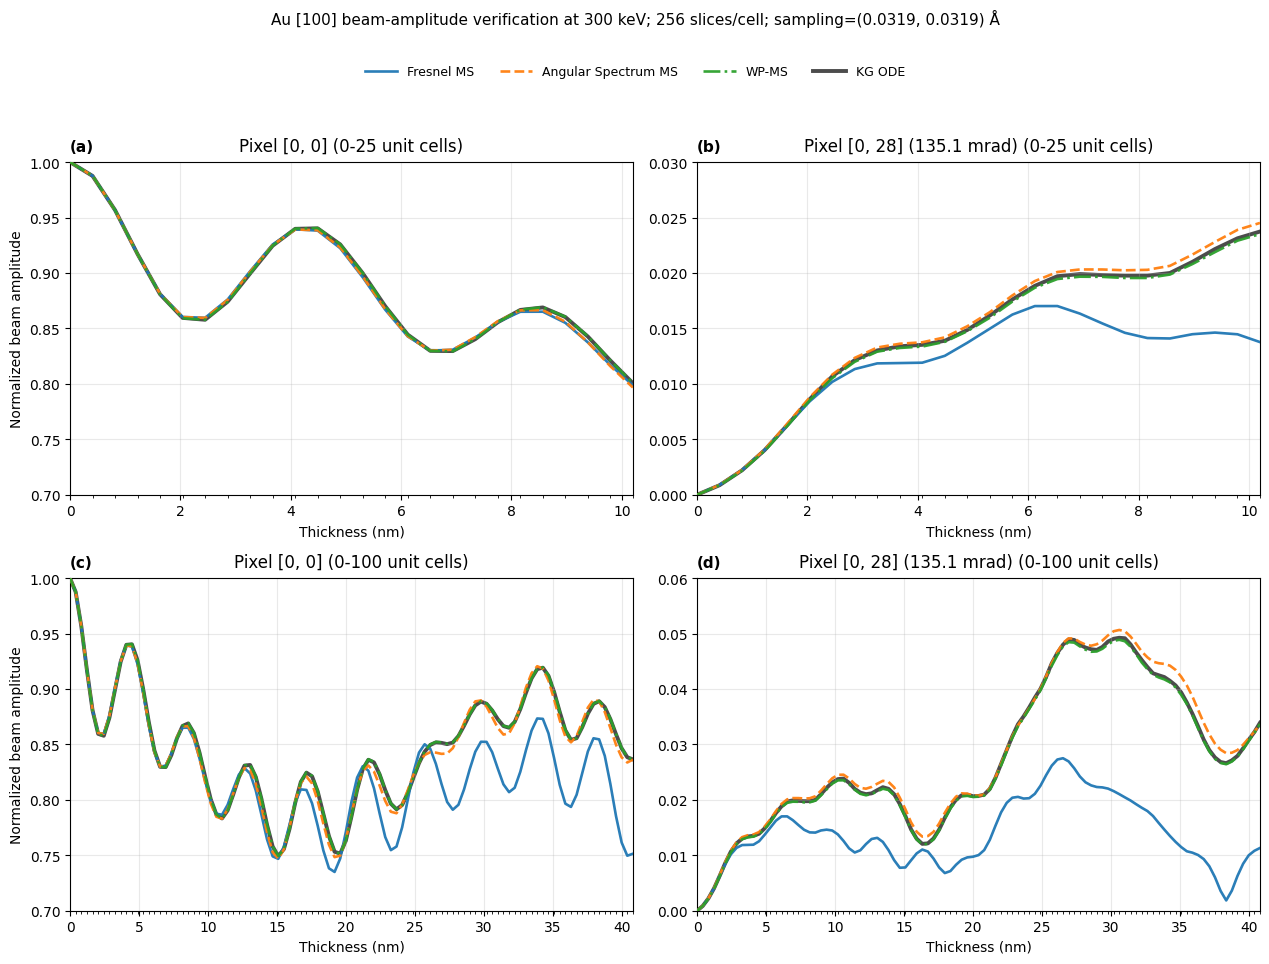

RMSE computed over the full simulated thickness range against KG ODE
Method                           Pixel [0, 0] RMSE Pixel [0, 28] (135.1 mrad) RMSE
----------------------------------------------------------------------------------
Fresnel MS                                0.034357                 0.016577
Angular Spectrum MS                       0.004574                 0.001221
WP-MS                                     0.000230                 0.000266


In [5]:
from matplotlib.ticker import MultipleLocator

x = np.array(list(n_cells_range), dtype=float)
full_mask = np.ones_like(x, dtype=bool)
first25_mask = x <= 25

cell_thickness_nm = float(cell_thickness) * 0.1

def unit_cells_to_nm(values):
    return np.asarray(values, dtype=float) * cell_thickness_nm

method_colors = {
    "Fresnel MS": "C0",
    "Angular Spectrum MS": "C1",
    "WP-MS": "C2",
    "KG ODE": "0.10",
}
method_line_styles = {
    "Fresnel MS": "-",
    "Angular Spectrum MS": "--",
    "WP-MS": "-.",
    "KG ODE": "-",
}
method_result_keys = {
    "Fresnel MS": "ms",
    "Angular Spectrum MS": "as",
    "WP-MS": "wpm",
}

methods_by_beam = {}
for beam_key, _, _, _ in tracked_beams:
    methods_by_beam[beam_key] = {
        name: beam_results[f"{result_key}_{beam_key}"]
        for name, result_key in method_result_keys.items()
    }
    methods_by_beam[beam_key]["KG ODE"] = kg_ode_results[beam_key]

ordered_labels = ["Fresnel MS", "Angular Spectrum MS", "WP-MS", "KG ODE"]
plot_order = ["KG ODE", "Fresnel MS", "Angular Spectrum MS", "WP-MS"]
panel_labels = [f"({chr(ord('a') + i)})" for i in range(2 * len(tracked_beams))]

n_beams_to_plot = len(tracked_beams)
fig, axes = plt.subplots(2, n_beams_to_plot, figsize=(6.4 * n_beams_to_plot, 10), sharey=False)
axes = np.asarray(axes).reshape(2, n_beams_to_plot)
legend_handles = {}

for col, (beam_key, _, _, beam_label) in enumerate(tracked_beams):
    for row, (x_mask, range_title) in enumerate(((first25_mask, "0-25 unit cells"), (full_mask, "0-100 unit cells"))):
        ax = axes[row, col]
        x_view = x[x_mask]
        x_view_nm = unit_cells_to_nm(x_view)
        for name in plot_order:
            y_view = np.asarray(methods_by_beam[beam_key][name])[x_mask]
            is_reference = name == "KG ODE"
            line, = ax.plot(
                x_view_nm,
                y_view,
                color=method_colors[name],
                linestyle=method_line_styles[name],
                linewidth=2.8 if is_reference else 1.9,
                alpha=0.78 if is_reference else 0.95,
                label=name,
                zorder=1 if is_reference else 3,
            )
            if name not in legend_handles:
                legend_handles[name] = line
        ax.set_title(f"{beam_label} ({range_title})", pad=8)
        ax.set_title(panel_labels[row * n_beams_to_plot + col], loc="left", fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Thickness (nm)")
        ax.grid(True, alpha=0.28)
        ax.set_xlim(x_view_nm.min(), x_view_nm.max())
        ax.xaxis.set_minor_locator(MultipleLocator(cell_thickness_nm))
        ax.tick_params(axis="x", which="minor", length=2.5)

# On-axis [0,0] beam — first two plots (top and bottom row of column 0)
axes[0, 0].set_ylim(0.7, 1.0)
axes[1, 0].set_ylim(0.7, 1.0)

# Off-axis beam(s) — column 1, different y-limit per row
if n_beams_to_plot >= 2:
    axes[0, 1].set_ylim(0.0, 0.030)
    axes[1, 1].set_ylim(0.0, 0.060)

axes[0, 0].set_ylabel("Normalized beam amplitude")
axes[1, 0].set_ylabel("Normalized beam amplitude")

fig.legend(
    [legend_handles[name] for name in ordered_labels],
    ordered_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=len(ordered_labels),
    frameon=False,
    fontsize=9,
    handlelength=2.6,
 )
fig.suptitle(
    f"Au [100] beam-amplitude verification at {energy/1e3:.0f} keV; "
    f"{n_slices_per_cell} slices/cell; sampling=({sampling[0]:.4f}, {sampling[1]:.4f}) Å",
    fontsize=11,
    y=1.01,
 )
fig.tight_layout(rect=[0.0, 0.05, 1.0, 0.93])
plt.show()

print("RMSE computed over the full simulated thickness range against KG ODE")
header = f"{'Method':<25s}" + "".join(f" {label + ' RMSE':>24s}" for _, _, _, label in tracked_beams)
print(header)
print("-" * len(header))
for name in ordered_labels:
    if name == "KG ODE":
        continue
    row = f"{name:<25s}"
    for beam_key, _, _, _ in tracked_beams:
        rmse = curve_rmse(methods_by_beam[beam_key][name], methods_by_beam[beam_key]["KG ODE"])
        row += f" {rmse:>24.6f}"
    print(row)


In [6]:
paper_fig_dir = resolve_paper_figures_dir()
paper_fig_dir.mkdir(parents=True, exist_ok=True)
output_path = paper_fig_dir / "Figure_4.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight", dpi=600)
if not output_path.exists() or output_path.stat().st_size == 0:
    raise RuntimeError(f"Failed to write figure: {output_path}")

old_first25_path = paper_fig_dir / "Au_pixel_amplitudes_first25_unit_cells.pdf"
if old_first25_path.exists():
    old_first25_path.unlink()

print(f"Saved -> {output_path}")
if not old_first25_path.exists():
    print(f"Removed obsolete separate first-25 figure -> {old_first25_path}")


Saved -> /home/dl277493/Documents/Code/WideAnglePropagation-main/Paper/figures/Figure_4.pdf
Removed obsolete separate first-25 figure -> /home/dl277493/Documents/Code/WideAnglePropagation-main/Paper/figures/Au_pixel_amplitudes_first25_unit_cells.pdf


## Exit-wave and image-plane comparison at final thickness

The columns show exit-wave intensity and phase, followed by the intensity after a representative aberration-corrected 300 keV HRTEM objective-lens transfer function. A residual $C_s = 10$ µm and a 12 mrad objective aperture are used. The positive defocus is selected so the aberration phase increases monotonically from zero to $+\pi/2$ at the aperture edge; consequently, the phase CTF $\sin(\chi)$ remains positive throughout the transmitted band and does not invert contrast. A 2 nm focal-spread envelope is also applied. Display ranges are shared by column so differences between propagation methods remain visible.


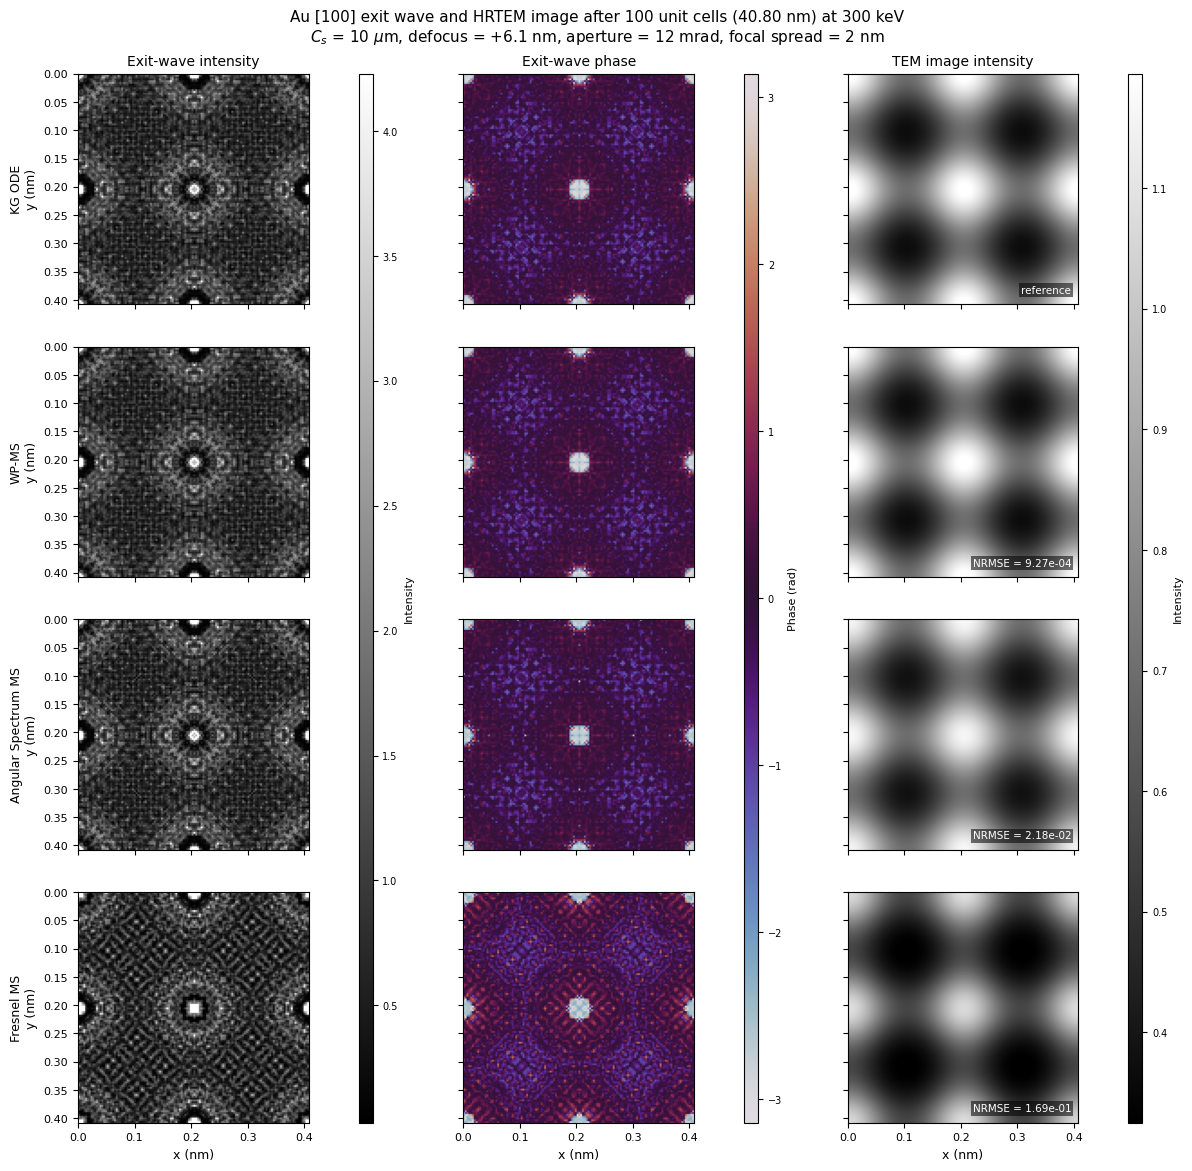

Representative aberration-corrected HRTEM transfer settings
Residual Cs: 10.0 um
Non-inverting defocus: +6.12 nm
Objective aperture semi-angle: 12.0 mrad
Phase at aperture edge: 0.50 pi
Focal spread: 2.0 nm

Image-plane intensity NRMSE against KG ODE
WP-MS                     9.269343e-04
Angular Spectrum MS       2.181197e-02
Fresnel MS                1.691850e-01


In [ ]:
exit_wave_methods = [
    ("KG ODE", w_kg),
    ("WP-MS", sweep_exit["wpm"]),
    ("Angular Spectrum MS", sweep_exit["as"]),
    ("Fresnel MS", sweep_exit["ms"]),
]


# Representative aberration-corrected 300 keV HRTEM settings. Choose the
# defocus so sin(chi) rises from 0 to +1 without a contrast reversal.
microscope_Cs_um = 10.0
microscope_Cs_A = microscope_Cs_um * 1e4
microscope_aperture_mrad = 12.0
microscope_aperture_rad = microscope_aperture_mrad * 1e-3
microscope_target_phase_rad = 0.5 * np.pi
microscope_defocus_A = (
    wavelength * microscope_target_phase_rad
    / (np.pi * microscope_aperture_rad**2)
    - 0.5 * microscope_Cs_A * microscope_aperture_rad**2
)
microscope_defocus_nm = microscope_defocus_A * 0.1
microscope_focal_spread_nm = 2.0

reference_shape = np.asarray(exit_wave_methods[0][1]).shape
objective_transfer = objective_lens_transfer_function(
    reference_shape,
    sampling,
    wavelength,
    microscope_defocus_A,
    microscope_Cs_A,
    microscope_aperture_mrad,
    microscope_focal_spread_nm,
)

exit_wave_intensities = {}
exit_wave_phases = {}
image_plane_intensities = {}

for name, wave in exit_wave_methods:
    wave = np.asarray(wave)
    exit_wave_intensities[name] = np.abs(wave) ** 2
    exit_wave_phases[name] = np.angle(global_phase_removed(wave))

    image_wave = np.fft.ifft2(np.fft.fft2(wave) * objective_transfer)
    image_plane_intensities[name] = np.abs(image_wave) ** 2

reference_image_intensity = image_plane_intensities["KG ODE"]
reference_image_rms = np.sqrt(np.mean(reference_image_intensity**2))
image_plane_nrmse = {
    name: np.sqrt(np.mean((values - reference_image_intensity) ** 2))
    / reference_image_rms
    for name, values in image_plane_intensities.items()
}

intensity_limits = shared_percentile_limits(exit_wave_intensities.values())
image_intensity_limits = shared_percentile_limits(image_plane_intensities.values())

extent_nm = [
    0.0,
    reference_shape[1] * sampling[1] * 0.1,
    reference_shape[0] * sampling[0] * 0.1,
    0.0,
]

n_methods = len(exit_wave_methods)
n_columns = 3
exit_fig = plt.figure(figsize=(11.8, 11.6), constrained_layout=True)
exit_grid = exit_fig.add_gridspec(
    n_methods,
    2 * n_columns,
    width_ratios=[1.0, 0.045, 1.0, 0.045, 1.0, 0.045],
    wspace=0.04,
)

exit_axes = np.empty((n_methods, n_columns), dtype=object)
reference_axis = None
for row in range(n_methods):
    for column in range(n_columns):
        axis_kwargs = {}
        if reference_axis is not None:
            axis_kwargs = {"sharex": reference_axis, "sharey": reference_axis}
        exit_axes[row, column] = exit_fig.add_subplot(
            exit_grid[row, 2 * column],
            **axis_kwargs,
        )
        if reference_axis is None:
            reference_axis = exit_axes[row, column]

colorbar_axes = [
    exit_fig.add_subplot(exit_grid[:, 2 * column + 1])
    for column in range(n_columns)
]

column_titles = [
    "Exit-wave intensity",
    "Exit-wave phase",
    "TEM image intensity",
]
for ax, title in zip(exit_axes[0], column_titles):
    ax.set_title(title, fontsize=10)

image_handles = [None] * n_columns
for row, (name, _) in enumerate(exit_wave_methods):
    values_by_column = [
        exit_wave_intensities[name],
        exit_wave_phases[name],
        image_plane_intensities[name],
    ]
    plot_options = [
        dict(cmap="gray", vmin=intensity_limits[0], vmax=intensity_limits[1]),
        dict(cmap="twilight", vmin=-np.pi, vmax=np.pi),
        dict(
            cmap="gray",
            vmin=image_intensity_limits[0],
            vmax=image_intensity_limits[1],
        ),
    ]

    for column, (ax, values, options) in enumerate(
        zip(exit_axes[row], values_by_column, plot_options)
    ):
        image_handles[column] = ax.imshow(values, extent=extent_nm, **options)
        ax.tick_params(labelsize=8)
        if row != n_methods - 1:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("x (nm)", fontsize=9)
        if column != 0:
            ax.tick_params(labelleft=False)

    exit_axes[row, 0].set_ylabel(f"{name}\ny (nm)", fontsize=9)
    if name == "KG ODE":
        comparison_text = "reference"
    else:
        comparison_text = f"NRMSE = {image_plane_nrmse[name]:.2e}"
    exit_axes[row, 2].text(
        0.97,
        0.04,
        comparison_text,
        transform=exit_axes[row, 2].transAxes,
        ha="right",
        va="bottom",
        fontsize=7.5,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.55, "edgecolor": "none", "pad": 1.5},
    )

colorbar_labels = ["Intensity", "Phase (rad)", "Intensity"]
for image_handle, colorbar_axis, label in zip(
    image_handles,
    colorbar_axes,
    colorbar_labels,
):
    colorbar = exit_fig.colorbar(image_handle, cax=colorbar_axis)
    colorbar.set_label(label, fontsize=8)
    colorbar.ax.tick_params(labelsize=7)

exit_fig.suptitle(
    f"Au [100] exit wave and HRTEM image after {x[-1]:.0f} unit cells "
    f"({unit_cells_to_nm([x[-1]])[0]:.2f} nm) at {energy/1e3:.0f} keV\n"
    f"$C_s$ = {microscope_Cs_um:.0f} $\\mu$m, defocus = "
    f"{microscope_defocus_nm:+.1f} nm, aperture = {microscope_aperture_mrad:.0f} mrad, "
    f"focal spread = {microscope_focal_spread_nm:.0f} nm",
    fontsize=11,
)
plt.show()

print("Representative aberration-corrected HRTEM transfer settings")
print(f"Cs: {microscope_Cs_um:.1f} um")
print(f"defocus: {microscope_defocus_nm:+.2f} nm")
print(f"Objective aperture semi-angle: {microscope_aperture_mrad:.1f} mrad")
print(f"Phase at aperture edge: {microscope_target_phase_rad / np.pi:.2f} pi")
print(f"Focal spread: {microscope_focal_spread_nm:.1f} nm")
print("\nImage-plane intensity NRMSE against KG ODE")
for name, _ in exit_wave_methods:
    if name != "KG ODE":
        print(f"{name:<25s} {image_plane_nrmse[name]:.6e}")


In [8]:
# Export exit-wave comparison figure for paper
if "exit_fig" not in globals():
    raise RuntimeError("Run the exit-wave comparison cell first so the figure exists.")

paper_fig_dir = resolve_paper_figures_dir()
paper_fig_dir.mkdir(parents=True, exist_ok=True)
exit_output_path = paper_fig_dir / "Figure_3.pdf"
exit_fig.savefig(exit_output_path, format="pdf", bbox_inches="tight", dpi=600)
if not exit_output_path.exists() or exit_output_path.stat().st_size == 0:
    raise RuntimeError(f"Failed to write figure: {exit_output_path}")

print(f"Saved -> {exit_output_path}")


Saved -> /home/dl277493/Documents/Code/WideAnglePropagation-main/Paper/figures/Figure_3.pdf


## RMSE summary vs KG ODE

In [9]:
print("% Paste into Paper/main.tex  ->  tab:rmse_verification")
print(r"\begin{tabular}{l" + "r" * len(tracked_beams) + "}")
print(r"    \toprule")
beam_headers = " & ".join(
    f"\\textbf{{RMSE ${label}$ vs KG ODE}}"
    for _, _, _, label in tracked_beams
)
print(r"    \textbf{Method} & " + beam_headers + r" \\")
print(r"    \midrule")
latex_names = {
    "Fresnel MS": r"Fresnel multislice",
    "Angular Spectrum MS": r"Angular-spectrum multislice",
    "WP-MS": r"WP-MS",
}
for name in ["Fresnel MS", "Angular Spectrum MS", "WP-MS"]:
    values = []
    for beam_key, *_ in tracked_beams:
        rmse = curve_rmse(methods_by_beam[beam_key][name], methods_by_beam[beam_key]["KG ODE"])
        values.append(f"{rmse:.4e}")
    print(f"    {latex_names[name]:<35s} & " + " & ".join(values) + r" \\")
print(r"    \bottomrule")
print(r"\end{tabular}")

% Paste into Paper/main.tex  ->  tab:rmse_verification
\begin{tabular}{lrr}
    \toprule
    \textbf{Method} & \textbf{RMSE $Pixel [0, 0]$ vs KG ODE} & \textbf{RMSE $Pixel [0, 28] (135.1 mrad)$ vs KG ODE} \\
    \midrule
    Fresnel multislice                  & 3.4357e-02 & 1.6577e-02 \\
    Angular-spectrum multislice         & 4.5736e-03 & 1.2208e-03 \\
    WP-MS                               & 2.2985e-04 & 2.6601e-04 \\
    \bottomrule
\end{tabular}


## Full-thickness numerical convergence

The publication calculation uses 256 slices per Au unit cell and 256 WP-MS
bins. The optional cells below reproduce the 64- and 512-slice refinements
for all four methods and the 512-bin WP-MS refinement over all 100 cells.
They are disabled by default because the ODE integrations are expensive.


In [10]:
RUN_ODE_SLICE_CONVERGENCE = False
SLICE_REFINEMENTS = (64, 512)
import json

def phase_aligned_relative_l2(values, reference):
    values = np.asarray(values)
    reference = np.asarray(reference)
    phase = np.angle(np.vdot(reference, values))
    return float(
        np.linalg.norm(values * np.exp(-1j * phase) - reference)
        / max(np.linalg.norm(reference), 1e-30)
    )

def build_au_ode_cell(slices_per_cell):
    dz = cell_thickness / slices_per_cell
    potential_builder = abtem.Potential(
        atoms, gpts=gpts, slice_thickness=dz,
        projection=POTENTIAL_PROJECTION, parametrization=POTENTIAL_PARAMETRIZATION,
    )
    local_sampling = tuple(float(value) for value in potential_builder.sampling)
    built = cupy.asnumpy(potential_builder.build(lazy=False).array)
    local_potential = jnp.asarray(built / dz, dtype=jnp.float64)
    del potential_builder, built
    cupy.get_default_memory_pool().free_all_blocks()
    return local_potential, local_sampling, dz

def run_ode_slice_refinement(slices_per_cell, bins=256, cells=100):
    local_potential, local_sampling, dz = build_au_ode_cell(slices_per_cell)
    local_fk = jnp.asarray(fresnel_propagation_kernel(*gpts, local_sampling, z=dz, energy=energy))
    local_ak = jnp.asarray(angular_spectrum_propagation_kernel(*gpts, local_sampling, z=dz, energy=energy))
    run_fresnel = jax.jit(lambda pot, wave: simulate_fresnel_as_exit_only(pot, wave, local_fk, dz, energy))
    run_angular = jax.jit(lambda pot, wave: simulate_fresnel_as_exit_only(pot, wave, local_ak, dz, energy))
    run_wpm = jax.jit(
        lambda pot, wave: simulate_wpm_exit_only(
            pot, wave, dz, energy, local_sampling, n_bins=bins, power_spacing=2.0
        )
    )

    method_names = ("fresnel", "as", "wpm", "ode")
    waves = {name: jnp.ones(gpts, dtype=jnp.complex128) for name in method_names}
    phi_ode = None
    curves = {
        f"{name}_{beam_key}": [beam_amplitude_normalized(np.asarray(waves[name]), h, k)]
        for name in method_names for beam_key, h, k, _ in tracked_beams
    }

    for cell_index in range(cells):
        waves["fresnel"] = run_fresnel(local_potential, waves["fresnel"])
        waves["as"] = run_angular(local_potential, waves["as"])
        waves["wpm"] = run_wpm(local_potential, waves["wpm"])
        waves["ode"], phi_ode, _, _ = simulate_kg_ode_full(
            local_potential, waves["ode"], dz, energy, local_sampling,
            initial_phi=phi_ode, rtol=1e-8, atol=1e-10, save_wavefronts=False,
        )
        jax.block_until_ready(waves["ode"])

        for name in method_names:
            wave_numpy = np.asarray(waves[name])
            for beam_key, h, k, _ in tracked_beams:
                curves[f"{name}_{beam_key}"].append(beam_amplitude_normalized(wave_numpy, h, k))
        if cell_index == 0 or (cell_index + 1) % 10 == 0:
            print(f"slices={slices_per_cell}, cell={cell_index + 1:3d}/{cells}")

    output = {
        "metadata_json": np.asarray(json.dumps({
            "description": "Au [100] ODE benchmark slice convergence",
            "energy_eV": float(energy),
            "lattice_constant_A": float(a_central),
            "gpts": list(gpts),
            "sampling_A": list(local_sampling),
            "slices_per_cell": int(slices_per_cell),
            "slice_thickness_A": float(dz),
            "wpm_bins": int(bins),
            "potential_parametrization": POTENTIAL_PARAMETRIZATION,
            "potential_projection": POTENTIAL_PROJECTION,
            "index_model": INDEX_MODEL,
            "precision": "float64",
            "jax_version": jax.__version__,
            "abtem_version": abtem.__version__,
        }, sort_keys=True)),
        "slices_per_cell": int(slices_per_cell),
        "slice_thickness_A": float(dz),
        "wpm_bins": int(bins),
        "n_cells": np.arange(cells + 1),
        **{name: np.asarray(values) for name, values in curves.items()},
        **{f"exit_{name}": np.asarray(wave) for name, wave in waves.items()},
    }

    baseline_path = results_dir / "au100_lobato_kg_ode_benchmark.npz"
    if baseline_path.exists():
        baseline_wave_keys = {
            "fresnel": "exit_fresnel", "as": "exit_as",
            "wpm": "exit_wpm", "ode": "exit_ode",
        }
        with np.load(baseline_path, allow_pickle=False) as baseline:
            for name, baseline_key in baseline_wave_keys.items():
                output[f"{name}_exit_phase_aligned_l2_vs_256_slices"] = (
                    phase_aligned_relative_l2(output[f"exit_{name}"], baseline[baseline_key])
                )

    output_path = results_dir / f"au100_ode_slice_convergence_s{slices_per_cell}.npz"
    np.savez_compressed(output_path, **output)
    print(f"Saved -> {output_path}")
    return output

if RUN_ODE_SLICE_CONVERGENCE:
    ode_slice_convergence = {
        slices: run_ode_slice_refinement(slices) for slices in SLICE_REFINEMENTS
    }
else:
    print("Set RUN_ODE_SLICE_CONVERGENCE=True to rerun the 64/512-slice refinements.")


Set RUN_ODE_SLICE_CONVERGENCE=True to rerun the 64/512-slice refinements.


In [11]:
RUN_WPM_BIN_CONVERGENCE = False
REFINED_WPM_BINS = 512

if RUN_WPM_BIN_CONVERGENCE:
    local_potential, local_sampling, dz = build_au_ode_cell(n_slices_per_cell)
    run_refined_wpm = jax.jit(
        lambda pot, wave: simulate_wpm_exit_only(
            pot, wave, dz, energy, local_sampling, n_bins=REFINED_WPM_BINS,
            power_spacing=2.0,
        )
    )
    refined_wave = jnp.ones(gpts, dtype=jnp.complex128)
    refined_curves = {
        beam_key: [beam_amplitude_normalized(np.asarray(refined_wave), h, k)]
        for beam_key, h, k, _ in tracked_beams
    }
    norm_ratio = [1.0]
    entrance_norm = float(jnp.sum(jnp.abs(refined_wave) ** 2))

    for cell_index in range(100):
        refined_wave = run_refined_wpm(local_potential, refined_wave)
        jax.block_until_ready(refined_wave)
        wave_numpy = np.asarray(refined_wave)
        for beam_key, h, k, _ in tracked_beams:
            refined_curves[beam_key].append(beam_amplitude_normalized(wave_numpy, h, k))
        norm_ratio.append(float(np.sum(np.abs(wave_numpy) ** 2) / entrance_norm))
        if cell_index == 0 or (cell_index + 1) % 10 == 0:
            print(f"bins={REFINED_WPM_BINS}, cell={cell_index + 1:3d}/100")

    output = {
        "metadata_json": np.asarray(json.dumps({
            "description": "Au [100] full-thickness WP-MS bin convergence",
            "energy_eV": float(energy),
            "lattice_constant_A": float(a_central),
            "gpts": list(gpts),
            "sampling_A": list(local_sampling),
            "slices_per_cell": int(n_slices_per_cell),
            "slice_thickness_A": float(dz),
            "wpm_bins": int(REFINED_WPM_BINS),
            "wpm_power_spacing": 2.0,
            "potential_parametrization": POTENTIAL_PARAMETRIZATION,
            "potential_projection": POTENTIAL_PROJECTION,
            "index_model": INDEX_MODEL,
            "precision": "float64",
            "jax_version": jax.__version__,
            "abtem_version": abtem.__version__,
        }, sort_keys=True)),
        "bins": int(REFINED_WPM_BINS),
        "slices_per_cell": int(n_slices_per_cell),
        "n_cells": np.arange(101),
        "norm_ratio": np.asarray(norm_ratio),
        "exit_wave": np.asarray(refined_wave),
        **{f"beam_{key}": np.asarray(values) for key, values in refined_curves.items()},
    }
    baseline_path = results_dir / "au100_lobato_kg_ode_benchmark.npz"
    if baseline_path.exists():
        with np.load(baseline_path, allow_pickle=False) as baseline:
            output["exit_phase_aligned_relative_l2_vs_256_bins"] = (
                phase_aligned_relative_l2(output["exit_wave"], baseline["exit_wpm"])
            )
            for beam_key, *_ in tracked_beams:
                baseline_key = f"wpm_{beam_key}"
                output[f"beam_{beam_key}_rmse_vs_256_bins"] = float(
                    np.sqrt(np.mean((output[f"beam_{beam_key}"] - baseline[baseline_key]) ** 2))
                )

    output_path = results_dir / "au100_wpm_bin_convergence.npz"
    np.savez_compressed(output_path, **output)
    print(f"Saved -> {output_path}")
else:
    print("Set RUN_WPM_BIN_CONVERGENCE=True to rerun the 512-bin refinement.")


Set RUN_WPM_BIN_CONVERGENCE=True to rerun the 512-bin refinement.
